In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

X = df[["Age", "EstimatedSalary"]].values
y = df["Purchased"].values

In [6]:
def handle_missing(X):
    X = X.copy().astype(int)
    
    for col in range(X.shape[1]):
        mean = np.nanmean(X[:, col])
        for i in range(len(X)):
            if np.isnan(X[i, col]):
                X[i, col] = mean
    
    return X

X = handle_missing(X)

In [8]:
def remove_duplicates(X, y):
    seen = set()
    X_new, y_new = [], []
    
    for i in range(len(X)):
        row = tuple(X[i])
        if row not in seen:
            seen.add(row)
            X_new.append(X[i])
            y_new.append(y[i])
    
    return np.array(X_new), np.array(y_new)

X, y = remove_duplicates(X, y)

In [10]:
def standardize(X):
    X_scaled = X.copy().astype(int)
    
    for col in range(X.shape[1]):
        mean = np.mean(X[:, col])
        std = np.std(X[:, col])
        X_scaled[:, col] = (X[:, col] - mean) / (std + 1e-8)
    
    return X_scaled

X = standardize(X)

In [11]:
def train_test_split(X, y, test_size=0.2):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    
    split = int(len(X) * (1 - test_size))
    
    return X[idx[:split]], X[idx[split:]], y[idx[:split]], y[idx[split:]]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


class LogisticRegressionScratch:
    
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None
        self.losses = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.epochs):
            linear = np.dot(X, self.w) + self.b
            y_pred = sigmoid(linear)
            
            # loss
            loss = -np.mean(y*np.log(y_pred+1e-8) + (1-y)*np.log(1-y_pred+1e-8))
            self.losses.append(loss)
            
            # gradients
            dw = np.dot(X.T, (y_pred - y)) / n_samples
            db = np.mean(y_pred - y)
            
            # update
            self.w -= self.lr * dw
            self.b -= self.lr * db
    
    def predict(self, X):
        y_prob = sigmoid(np.dot(X, self.w) + self.b)
        return (y_prob > 0.5).astype(int)

In [13]:
model = LogisticRegressionScratch(lr=0.01, epochs=1000)
model.fit(X_train, y_train)

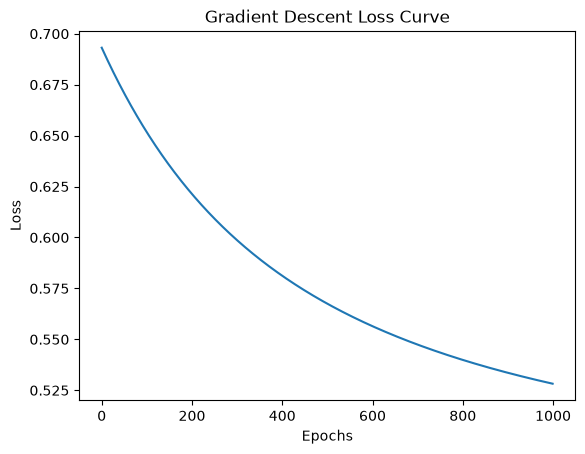

In [14]:
plt.plot(model.losses)
plt.title("Gradient Descent Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [28]:
def confusion_matrix(y_true, y_pred):
    TP = FP = TN = FN = 0
    
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        elif y_true[i] == 0 and y_pred[i] == 0:
            TN += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
    
    return TP, FP, TN, FN


y_pred = model.predict(X_test)
TP, FP, TN, FN = confusion_matrix(y_test, y_pred)

print("TP:", TP, "FP:", FP, "TN:", TN, "FN:", FN)

TP: 21 FP: 3 TN: 43 FN: 6


In [29]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy:", accuracy)

Accuracy: 0.8767123287671232
